# RavenStack — growth & retention analysis

Working notebook for the PM case study. The SQL in `../analysis/` carries the
metric definitions; this notebook is where I poke at things that are awkward in
SQL (cohorts, activation thresholds, per-feature stuff) and make the charts
that end up in `../images/` and the memo.

Data: synthetic B2B SaaS dataset by River @ Rivalytics (Kaggle). 500 accounts,
5k subscriptions, 25k usage events, 2k tickets, 600 churn events. Window is
Jan 2023 – Dec 2024. Everything below is on synthetic data — fine for
methodology, dont quote it as market truth.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import os  # eh, might need for paths later

import warnings; warnings.filterwarnings('ignore')

RAW = '../data/raw'
accts = pd.read_csv(f'{RAW}/ravenstack_accounts.csv', parse_dates=['signup_date'])
subs = pd.read_csv(f'{RAW}/ravenstack_subscriptions.csv', parse_dates=['start_date', 'end_date'])
fu = pd.read_csv(f'{RAW}/ravenstack_feature_usage.csv', parse_dates=['usage_date'])
st = pd.read_csv(f'{RAW}/ravenstack_support_tickets.csv', parse_dates=['submitted_at', 'closed_at'])
ce = pd.read_csv(f'{RAW}/ravenstack_churn_events.csv', parse_dates=['churn_date'])

for df in (accts, subs, fu, st, ce):
    print(df.shape)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

(500, 10)
(5000, 14)
(25000, 8)
(2000, 9)
(600, 9)


In [2]:
accts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [3]:
# usage is only valid between signup and churn. the generator scatters
# usage across the whole 2-year window (13k of 25k events PREDATE signup!), so
# bound it on both sides or every lifetime metric is junk
last_churn = ce[ce.account_id.isin(accts[accts.churn_flag].account_id)].groupby('account_id').churn_date.max()
fu2 = fu.merge(subs[['subscription_id', 'account_id']], on='subscription_id')
fu2 = fu2.merge(accts[['account_id', 'signup_date']], on='account_id')
fu2 = fu2.merge(last_churn.rename('churn_date'), on='account_id', how='left')
fu_pre = fu2[
    (fu2.usage_date >= fu2.signup_date)
    & (fu2.churn_date.isna() | (fu2.usage_date <= fu2.churn_date))
].copy()
len(fu), len(fu_pre)  # dropped pre-signup + post-churn events

(25000, 11126)

## The three churn numbers

Same dataset, three definitions, people quote all three as "churn". Pinning
them down first so nothing later is ambigious (full definitions in
analysis/README.md):

In [4]:
pd.Series({
    'account churn (churn_flag)': accts.churn_flag.mean(),
    'subscription churn': subs.churn_flag.mean(),
    'accounts with >=1 churn event': ce.account_id.nunique() / len(accts),
}).mul(100).round(1)

account churn (churn_flag)       22.0
subscription churn                9.7
accounts with >=1 churn event    70.4
dtype: float64

22.0% account churn vs 9.7% subscription churn. The 600 churn events mostly sit
on accounts that are still customers (billing-level churn / mid-relationship
events + 61 reactivations), so event counts are only used for reason codes.

## Where retention breaks down

Account churn by segment. n's in the labels, some of these slices are thin.

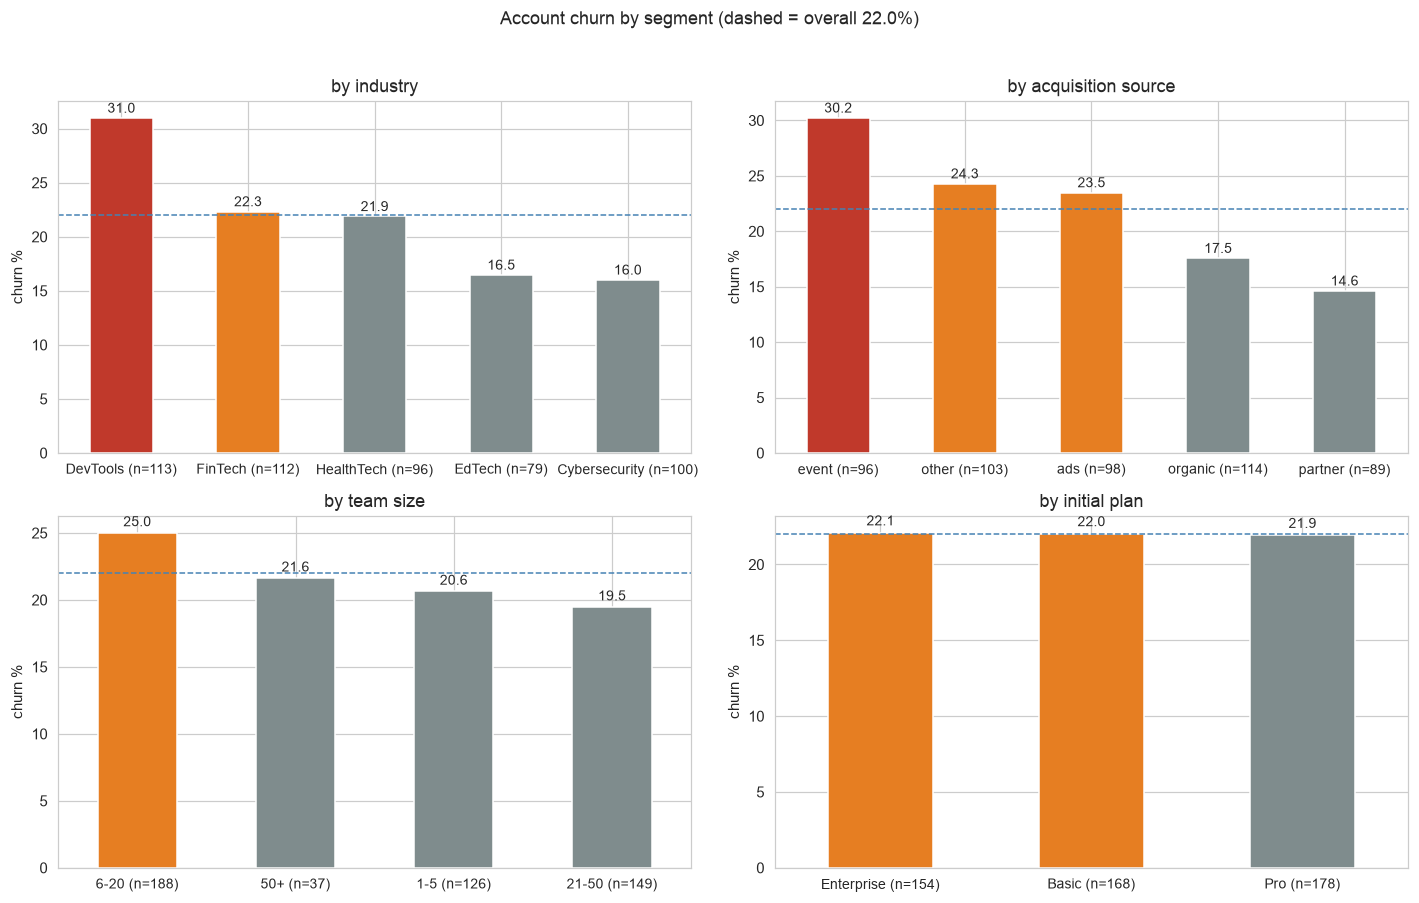

In [5]:
def seg_churn(df, col, order=None, ax=None, title=''):
    gg = df.groupby(col).agg(n=('account_id', 'count'), churned=('churn_flag', 'sum'))
    gg['pct'] = 100 * gg.churned / gg.n
    gg = gg.sort_values('pct', ascending=False)
    colors = ['#c0392b' if p > 25 else '#e67e22' if p > 22 else '#7f8c8d' for p in gg.pct]
    gg.pct.plot.bar(ax=ax, color=colors)
    ax.set_title(title); ax.set_ylabel('churn %'); ax.set_xlabel('')
    ax.set_xticklabels([f'{i} (n={n})' for i, n in zip(gg.index, gg.n)], rotation=0, fontsize=9)
    for i, p in enumerate(gg.pct):
        ax.text(i, p + 0.5, f'{p:.1f}', ha='center', fontsize=9)
    return gg

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
seg_churn(accts, 'industry', ax=axes[0][0], title='by industry')
seg_churn(accts, 'referral_source', ax=axes[0][1], title='by acquisition source')
accts['seat_bucket'] = pd.cut(accts.seats, [0, 5, 20, 50, 999], labels=['1-5', '6-20', '21-50', '50+'])
seg_churn(accts, 'seat_bucket', ax=axes[1][0], title='by team size')
seg_churn(accts, 'plan_tier', ax=axes[1][1], title='by initial plan')
overall = accts.churn_flag.mean() * 100
for ax in axes.flat: ax.axhline(overall, ls='--', c='steelblue', lw=1)
plt.suptitle(f'Account churn by segment (dashed = overall {overall:.1f}%)', y=1.02)
plt.tight_layout()
plt.savefig('../images/churn_by_segment.png', bbox_inches='tight', dpi=150); plt.show()

- **DevTools churns at 31.0%** vs 16.0% Cybersecurity — nearly 2x across the bookends
- **Event-sourced accounts churn at 30.2%**, partner at 14.6%. Also ~2x.
- Mid-size teams (6–20 seats) are the weakest size band
- Plan tier: flat. Churn *rate* doesn't care about plan — revenue at risk does (later)

Is the event-vs-partner gap just noise? Quick check:

In [6]:
tab = pd.crosstab(accts.referral_source, accts.churn_flag)
chi2, p, dof, _ = chi2_contingency(tab)
print(f'referral x churn: chi2={chi2:.2f}, p={p:.4f}')

tab2 = pd.crosstab(accts.industry, accts.churn_flag)
chi2, p2, dof, _ = chi2_contingency(tab2)
print(f'industry x churn: chi2={chi2:.2f}, p={p2:.4f}')

# pairwise: event vs partner only
tp = pd.crosstab(accts[accts.referral_source.isin(['event','partner'])].referral_source,
                 accts[accts.referral_source.isin(['event','partner'])].churn_flag)
chi2, p3, dof, _ = chi2_contingency(tp)
print(f'event vs partner: chi2={chi2:.2f}, p={p3:.4f}')

referral x churn: chi2=8.36, p=0.0794
industry x churn: chi2=8.82, p=0.0657
event vs partner: chi2=5.55, p=0.0185


Omnibus tests are borderline (referral p=0.079, industry p=0.066 — with five
cells each the omnibus dilutes fast at n=500), but the contrast that matters,
event vs partner, is clean: chi2=5.55, p=0.018. Not proof of cause, not noise
either. Crossing the two main signals:

In [7]:
cross = accts.groupby(['industry', 'referral_source']).agg(
    n=('account_id', 'count'), churn_pct=('churn_flag', lambda s: 100*s.mean())).reset_index()
cross[cross.n >= 15].sort_values('churn_pct', ascending=False).round(1).head(8)

,industry,referral_source,n,churn_pct
6,DevTools,event,23,43.5
5,DevTools,ads,26,38.5
15,FinTech,ads,22,31.8
21,HealthTech,event,16,31.2
8,DevTools,other,24,29.2
3,Cybersecurity,other,20,25.0
7,DevTools,organic,24,25.0
18,FinTech,other,25,24.0


DevTools × event = 43.5% churn (n=23) vs DevTools × partner = 12.5% (n=16).
Tiny cells, directional only, but it keeps pointing the same way: *who we
acquire* and *what vertical they're in* matters more than anything in-product
I can find. Which is the next section.

## Does behaviour explain churn? (mostly no)

Usage summary, retained vs churned, valid window only (signup → churn):

In [9]:
uagg = fu_pre.groupby('account_id').agg(
    events=('usage_id', 'count'),
    features=('feature_name', 'nunique'),
    usage_count=('usage_count', 'sum'),
    hours=('usage_duration_secs', lambda s: s.sum()/3600),
    errors=('error_count', 'sum'),
    beta=('is_beta_feature', 'sum')).reset_index()
uagg = uagg.merge(accts[['account_id', 'churn_flag']], on='account_id')
uagg.groupby('churn_flag')[uagg.columns[1:-1]].mean().round(1)

,events,features,usage_count,hours,errors,beta
churn_flag,,,,,,
False,23.4,16.0,233.8,19.6,13.0,2.2
True,21.2,14.9,213.2,17.9,11.2,2.3


In [8]:
# support side. same story?
sagg = st.groupby('account_id').agg(
    tickets=('ticket_id', 'count'),
    res_h=('resolution_time_hours', 'mean'),
    frt_min=('first_response_time_minutes', 'mean'),
    csat=('satisfaction_score', 'mean'),
    escalations=('escalation_flag', 'sum')).reset_index()
sagg = sagg.merge(accts[['account_id', 'churn_flag']], on='account_id')
sagg.groupby('churn_flag')[sagg.columns[1:-1]].mean().round(2)

,tickets,res_h,frt_min,csat,escalations
churn_flag,,,,,
False,4.08,36.45,89.58,3.95,0.18
True,4.00,35.49,84.93,4.00,0.22


In [10]:
# usage intensity in the windows before churn — looking for a death dip
w = fu_pre[fu_pre.churn_date.notna()].copy()
w['d'] = (w.churn_date - w.usage_date).dt.days
bn = [(0, 30, 'last 30d'), (31, 90, 'd31-90'), (91, 150, 'd91-150')]
pd.Series({lbl: w[(w.d >= lo) & (w.d <= hi)].usage_count.mean() for lo, hi, lbl in bn}).round(1)

last 30d     9.9
d31-90      10.0
d91-150      9.9
dtype: float64

Usage volume, breadth, errors, beta usage: churned accounts look basically
like retained ones (slightly *lower* usage if anything). CSAT identical,
response times slightly *faster* for churned. No death dip before churn —
usage is flat right up to the end. Support escalations are the only thing
that moves (0.22 vs 0.18 per account, 20.9% vs 17.4% of accounts hit by >=1
escalation) and it's a modest signal, not a smoking gun.

This is genuinely useful: **the retention problem does not look like an
engagement problem.** Which pushes us to what customers *say*.

## Why they say they leave

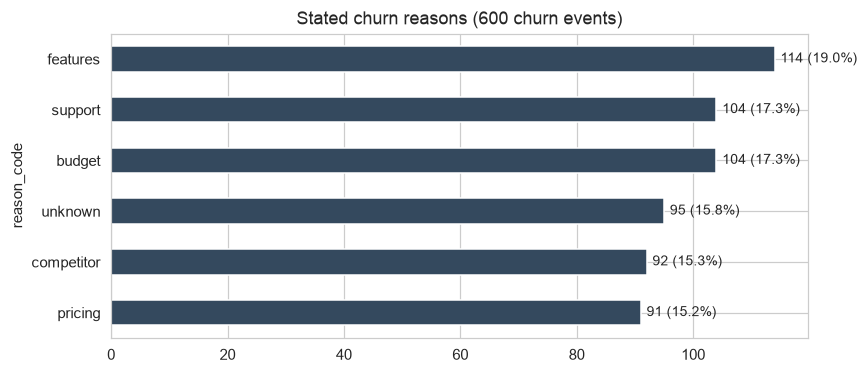

In [11]:
reasons = ce.reason_code.value_counts()
fig, ax = plt.subplots(figsize=(8, 3.5))
reasons.plot.barh(ax=ax, color='#34495e')
ax.invert_yaxis()
ax.set_title('Stated churn reasons (600 churn events)')
for i, (r, n) in enumerate(reasons.items()):
    ax.text(n + 1, i, f'{n} ({100*n/len(ce):.1f}%)', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('../images/churn_reasons.png', bbox_inches='tight', dpi=150); plt.show()

In [12]:
# reasons x plan — plan is the account's initial plan
rp = ce.merge(accts[['account_id', 'plan_tier']], on='account_id').pivot_table(
    index='plan_tier', columns='reason_code', values='churn_event_id', aggfunc='count')
rp = rp.loc[['Basic', 'Pro', 'Enterprise']]
rp.div(rp.sum(axis=1), axis=0).mul(100).round(1)

reason_code,budget,competitor,features,pricing,support,unknown
plan_tier,,,,,,
Basic,16.7,13.9,18.9,16.1,20.6,13.9
Pro,17.8,16.0,18.2,13.3,19.1,15.6
Enterprise,17.4,15.9,20.0,16.4,12.3,17.9


Features is the #1 code overall (19.0%) and the clear leader for Enterprise.
Basic and Pro lead with support. Budget + pricing together are ~1/3 — pricing
pressure is real too. 'Unknown' at 15.8% is annoyingly large; the feedback
text on those rows is too generic to mine (three canned phrases, its
synthetic data).

## What it costs — frequency ≠ impact

In [14]:
lost_arr = subs[subs.churn_flag].groupby('plan_tier').agg(
    churned_subs=('subscription_id', 'count'),
    mrr_lost=('mrr_amount', 'sum'),
    arr_lost=('arr_amount', 'sum')).sort_values('arr_lost', ascending=False)
lost_arr['share_of_arr_lost_%'] = 100 * lost_arr.arr_lost / lost_arr.arr_lost.sum()
lost_arr.round(0)

,churned_subs,mrr_lost,arr_lost,share_of_arr_lost_%
plan_tier,,,,
Enterprise,172,926345,11116140,79.0
Pro,162,180271,2163252,15.0
Basic,152,72523,870276,6.0


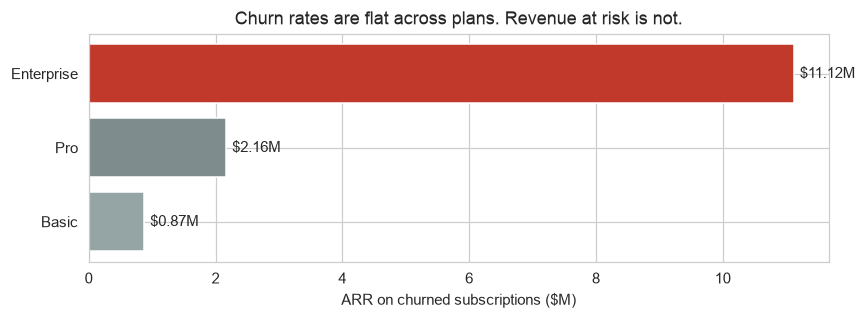

In [15]:
fig, ax = plt.subplots(figsize=(8, 3))
plt.barh(lost_arr.index[::-1], lost_arr.arr_lost[::-1] / 1e6, color=['#95a5a6', '#7f8c8d', '#c0392b'])
ax.set_xlabel('ARR on churned subscriptions ($M)')
ax.set_title('Churn rates are flat across plans. Revenue at risk is not.')
for i, v in enumerate(lost_arr.arr_lost[::-1] / 1e6):
    ax.text(v + 0.1, i, f'${v:.2f}M', va='center', fontsize=10)
plt.tight_layout(); plt.savefig('../images/revenue_exposure.png', bbox_inches='tight', dpi=150); plt.show()

$14.15M ARR sits on churned subscriptions; **Enterprise is 78.6% of it**
($11.12M). So "which segment churns most" and "which segment should we work
on" have different answers — DevTools/event for frequency, Enterprise for
dollars. Ideally the fix overlaps both.

## Cohort retention

Activity-based: an account is "retained in month m" if it has >=1 usage event
in month m after signup. 2023 cohorts only (they get the full 12 months of
window; later cohorts are censored and would fake a decay).

In [16]:
a = fu_pre.copy()
a['dow'] = a.usage_date.dt.dayofweek  # was curious about weekday effects, never went anywhere
a['month_index'] = (a.usage_date.dt.year - a.signup_date.dt.year) * 12 + (a.usage_date.dt.month - a.signup_date.dt.month)
act_cells = a[(a.month_index >= 0) & (a.month_index <= 11) & (a.month_index.notna())].groupby(
    ['account_id', 'month_index']).size().reset_index()[['account_id', 'month_index']]

cohorts = accts[accts.signup_date < '2024-01-01'].copy()
cohorts['cohort'] = cohorts.signup_date.dt.to_period('M').astype(str)
sizes = cohorts.groupby('cohort').account_id.nunique()
piv = (act_cells.merge(cohorts[['account_id', 'cohort']], on='account_id')
       .groupby(['cohort', 'month_index']).account_id.nunique().unstack()
       .reindex(columns=range(12)))
retmat = piv.div(sizes, axis=0) * 100
retmat.round(0)

month_index,0,1,2,3,4,5,6,7,8,9,10,11
cohort,,,,,,,,,,,,
2023-01,47.0,71.0,88.0,94.0,88.0,71.0,88.0,94.0,82.0,82.0,65.0,65.0
2023-02,61.0,89.0,89.0,72.0,83.0,78.0,83.0,67.0,94.0,89.0,78.0,89.0
2023-03,55.0,95.0,90.0,75.0,85.0,75.0,80.0,70.0,80.0,65.0,65.0,70.0
2023-04,67.0,87.0,87.0,87.0,93.0,73.0,93.0,80.0,80.0,100.0,100.0,93.0
2023-05,73.0,85.0,88.0,88.0,88.0,92.0,81.0,88.0,96.0,92.0,77.0,85.0
2023-06,54.0,85.0,92.0,92.0,69.0,77.0,85.0,100.0,85.0,92.0,77.0,85.0
2023-07,64.0,86.0,79.0,93.0,86.0,93.0,93.0,93.0,93.0,86.0,86.0,93.0
2023-08,56.0,88.0,94.0,88.0,81.0,75.0,94.0,94.0,94.0,81.0,94.0,88.0
2023-09,74.0,78.0,91.0,96.0,100.0,87.0,87.0,78.0,91.0,74.0,61.0,78.0


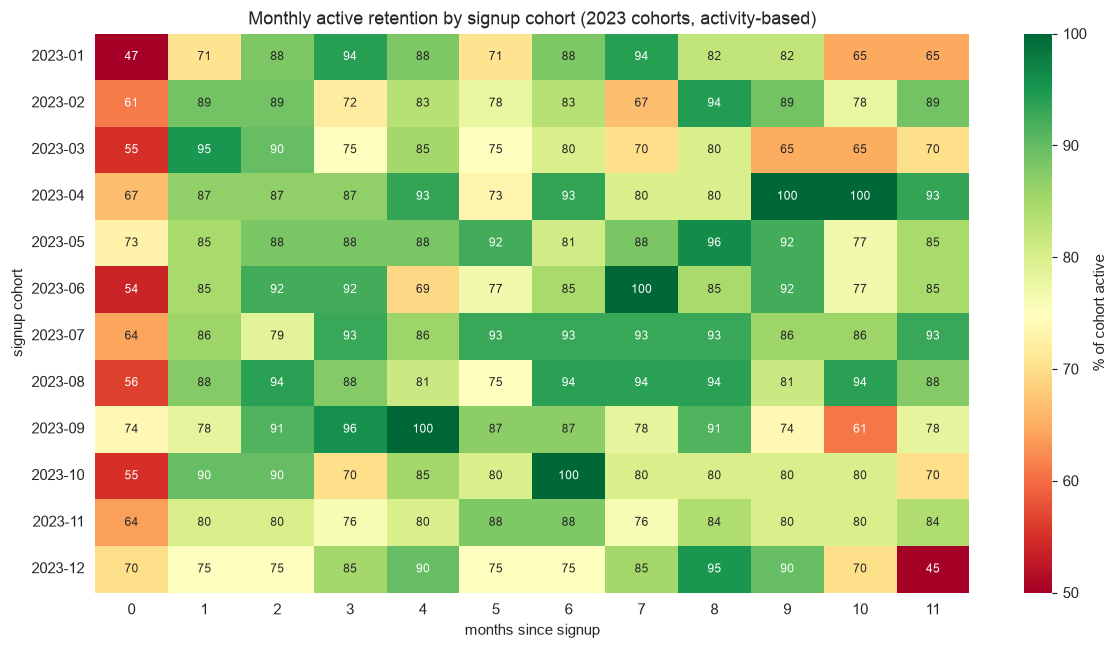

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(retmat, annot=True, fmt='.0f', cmap='RdYlGn', vmin=50, vmax=100,
            cbar_kws={'label': '% of cohort active'}, annot_kws={'size': 8}, ax=ax)
ax.set_xlabel('months since signup'); ax.set_ylabel('signup cohort')
ax.set_title('Monthly active retention by signup cohort (2023 cohorts, activity-based)')
plt.tight_layout(); plt.savefig('../images/cohort_retention.png', bbox_inches='tight', dpi=150); plt.show()

In [18]:
# kernel restarted somewhere above (or i closed it, who knows), re-set styles
sns.set_style('whitegrid'); plt.rcParams['figure.dpi'] = 110

Retention is sticky-ish month to month (mid-70s to 90s) with no structural
decay over the first year — again, not an engagement-death product. The
interesting movement is *between* segments. Pooled curves by acquisition
source (2023 cohorts, equal window):

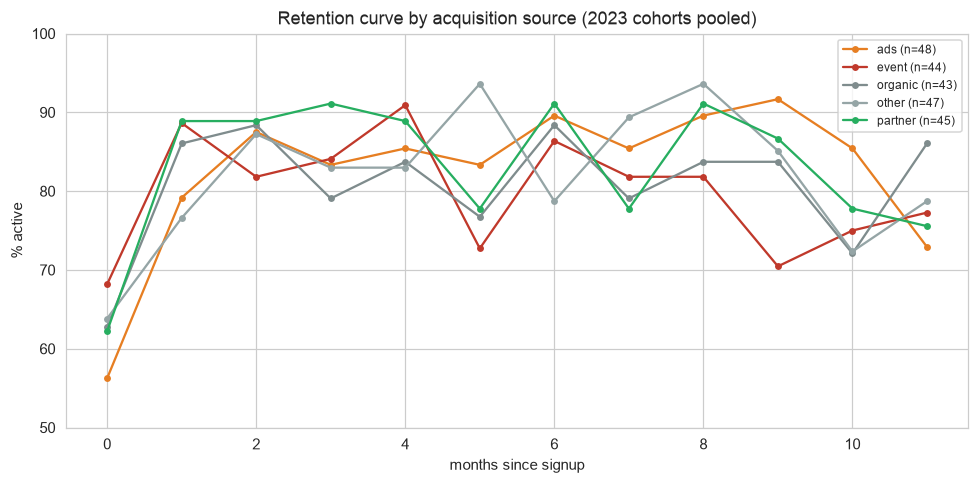

In [19]:
p_by_src = (act_cells.merge(cohorts[['account_id', 'referral_source']], on='account_id')
         .groupby(['referral_source', 'month_index']).account_id.nunique().unstack()
         .reindex(columns=range(12)))
n_by_src = cohorts.groupby('referral_source').account_id.nunique()
pct_by_src = p_by_src.div(n_by_src, axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {'event': '#c0392b', 'partner': '#27ae60', 'ads': '#e67e22', 'organic': '#7f8c8d', 'other': '#95a5a6'}
for src in pct_by_src.index:
    ax.plot(pct_by_src.columns, pct_by_src.loc[src], marker='o', ms=3.5, label=f'{src} (n={n_by_src[src]})', color=colors.get(src))
ax.set_xlabel('months since signup'); ax.set_ylabel('% active')
ax.set_title('Retention curve by acquisition source (2023 cohorts pooled)')
ax.legend(fontsize=8); ax.set_ylim(50, 100)
plt.tight_layout(); plt.savefig('../images/retention_by_referral.png', bbox_inches='tight', dpi=150); plt.show()

Event-acquired accounts don't faceplant in month 1 — they **slide from ~month
6 on** (still ~89% at M6, ~75% by M9) while partner holds 90%+. That's a
lifecycle/expectation problem more than an onboarding-day-one problem, which
changes what I'd build: not a welcome tour, more like value reinforcement +
checkpoints around the month 4–6 window where the slide starts.

## Activation: is there a magic threshold?

Sweep it instead of guessing it. Distinct features in first 30 days vs
eventual churn (signups with 6+ months of window):

In [20]:
base = accts[accts.signup_date <= '2024-06-30'][['account_id', 'churn_flag']].copy()
dd = (fu_pre.usage_date - fu_pre.signup_date).dt.days
f30 = fu_pre[dd <= 30].groupby('account_id').feature_name.nunique()
base['feats_30d'] = base.account_id.map(f30).fillna(0).astype(int)
base['bucket'] = pd.cut(base.feats_30d, [-1, 2, 5, 10, 15, 99],
                        labels=['0-2', '3-5', '6-10', '11-15', '16+'])
sweep_b = base.groupby('bucket', observed=True).agg(n=('churn_flag', 'count'),
                                               churn_pct=('churn_flag', lambda s: 100*s.mean())).round(1)
sweep_b

,n,churn_pct
bucket,,
0-2,221,24.0
3-5,119,25.2
6-10,8,12.5


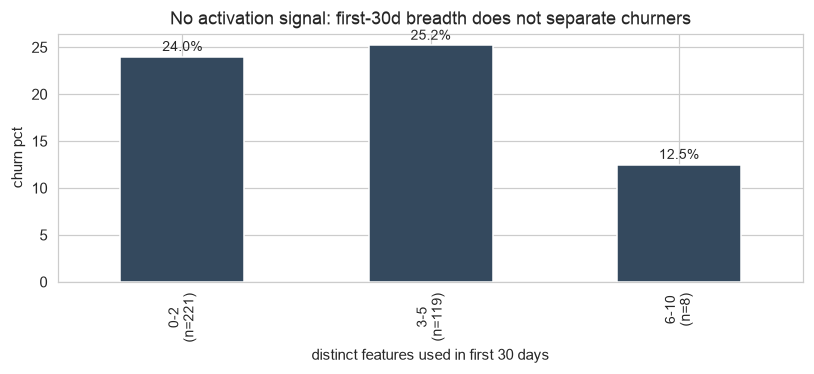

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 3.5))
sweep_b.churn_pct.plot.bar(ax=ax, color='#34495e')
ax.set_xlabel('distinct features used in first 30 days'); ax.set_ylabel('churn pct')
ax.set_title('No activation signal: first-30d breadth does not separate churners')
ax.set_xticklabels([f'{i}\n(n={n})' for i, n in sweep_b.n.items()], fontsize=9)
for i, p in enumerate(sweep_b.churn_pct):
    ax.text(i, p + 0.6, f'{p:.1f}%', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('../images/activation_threshold.png', bbox_inches='tight', dpi=150); plt.show()

And it's flat. 24.0% churn at 0–2 features vs 25.2% at 3–5 — if anything
slightly backwards — and the 6–10 bucket is 8 accounts, i.e. noise. There is
no activation signal in first-30-day breadth in this dataset, let alone a
threshold. That's a stronger statement than the weak-gradient story I had
before bounding usage to post-signup (53% of usage events predate signup and
were polluting the early-life windows — see the setup cell).

What I *would* take into the product team: breadth-of-adoption can't be
proxied by feature count here, and we should instrument a real activation
metric (first team-invite? first core-workflow completion?) rather than proxy
it. If breadth doesn't separate churners, "get users to touch more features"
is not a defensible retention bet on this evidence.

## Feature-level signals

Every account-level feature flag I can build, tested against churn. Adopter
= used the feature in first 60 days; base = same 6+ month window as above.
Features are anonymised (feature_0..39), so this is really asking "is any
single feature load-bearing":

In [22]:
# first pass did this with one giant pivot table, unreadable. loop is slower, whatever
# piv = f60.pivot_table(index='account_id', columns='feature_name', aggfunc='size')
f60 = fu_pre[(fu_pre.usage_date - fu_pre.signup_date).dt.days <= 60][['account_id', 'feature_name']].drop_duplicates()

rows = []
for f in sorted(f60.feature_name.unique()):
    ad = set(f60.loc[f60.feature_name == f, 'account_id'])
    b = base.copy(); b['adopter'] = b.account_id.isin(ad)
    r = b.groupby('adopter').churn_flag.agg(['count', 'mean'])
    rows.append({'feature': f, 'adopters': int(r['count'].get(True, 0)),
                 'adopter_churn': 100*r['mean'].get(True, np.nan),
                 'nonadopter_churn': 100*r['mean'].get(False, np.nan)})
fdf = pd.DataFrame(rows)
fdf['delta'] = fdf.adopter_churn - fdf.nonadopter_churn
fdf.round(1).sort_values('delta').head(5), fdf.round(1).sort_values('delta').tail(5)

(       feature  adopters  adopter_churn  nonadopter_churn  delta
 14  feature_22        32           12.5              25.3  -12.8
 27  feature_34        35           14.3              25.2  -11.0
 15  feature_23        34           14.7              25.2  -10.5
 39   feature_9        39           15.4              25.2   -9.9
 13  feature_21        33           15.2              25.1   -9.9,
        feature  adopters  adopter_churn  nonadopter_churn  delta
 22   feature_3        33           33.3              23.2   10.2
 37   feature_7        51           33.3              22.6   10.8
 5   feature_14        29           34.5              23.2   11.3
 31  feature_38        39           38.5              22.3   16.1
 0    feature_1        29           55.2              21.3   33.9)

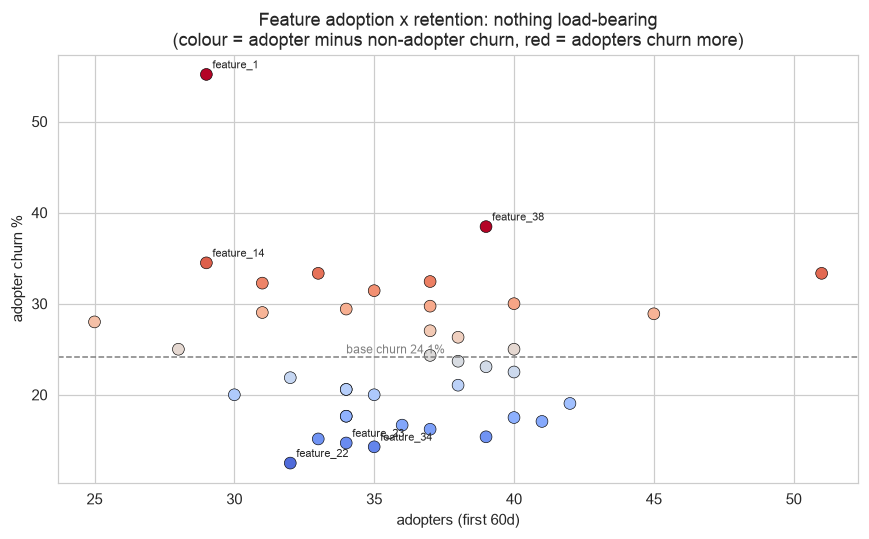

In [23]:
overall_base = 100 * base.churn_flag.mean()
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fdf.adopters, fdf.adopter_churn, s=60, c=fdf.delta, cmap='coolwarm',
           vmin=-15, vmax=15, edgecolor='k', linewidth=.4)
ax.axhline(overall_base, ls='--', c='gray', lw=1)
ax.text(34, overall_base + 0.4, f'base churn {overall_base:.1f}%', fontsize=8, color='gray')
for _, r in pd.concat([fdf.nsmallest(3, 'delta'), fdf.nlargest(3, 'delta')]).iterrows():
    ax.annotate(r.feature, (r.adopters, r.adopter_churn), fontsize=7,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('adopters (first 60d)'); ax.set_ylabel('adopter churn %')
ax.set_title('Feature adoption x retention: nothing load-bearing\n(colour = adopter minus non-adopter churn, red = adopters churn more)')
plt.tight_layout(); plt.savefig('../images/feature_analysis.png', bbox_inches='tight', dpi=150); plt.show()

With the corrected window the adopter cells are small (~35 accounts per
feature), so a couple of accounts swing these percentages — the spread looks
dramatic (12.5% to ~30% adopter churn) but nothing here would clear a
significance bar, and adoption is still near-uniform across features
(consistent with the uniform synthetic generator). Verdict unchanged:
**no feature-level smoking gun**. I'd rather report a boring true result
than a shiny fabricated one.

## Where this leaves us

1. Retention problem is concentrated, not general: DevTools (31%), event-sourced (30.2%), 6–20 seats (25%). Plan tier flat. Churners leave fast: median tenure ~5 months.
2. It is NOT an engagement-volume problem: churned accounts use the product about as much, no pre-churn dip, CSAT equal.
3. Customers point at **feature gaps** first (19%, and #1 for Enterprise where 78.6% of the at-risk ARR sits), then budget/pricing/support.
4. Event-source accounts degrade late (M6+), not at onboarding — expectation/value drift, not a broken first-run.
5. No activation signal: first-30d feature breadth is flat against churn (24.0% vs 25.2%), and no single feature is load-bearing (adopter cells too small to trust).

Next: the memo (product/product_recommendation_memo.md) turns this into a
recommendation + experiment.

In [ ]:
# parked: wanted to do retention curves by country, but ~60% of accounts are US
# and the rest are thin slices, curves were noise. also tried errors-by-feature
# x churn and it went nowhere. leaving this here in case i come back to it.
# us = accts[accts.country=='US'] ...